# PYIN によるピッチ追跡と F0 推定手法の比較

PYIN（Probabilistic YIN）は、確率的モデルと HMM（隠れマルコフモデル）を組み合わせた現在の標準的な F0 推定手法。  
有声/無声判定を同時に行い、オクターブエラーに強い。

## このノートブックで学ぶこと

1. PYIN の動作原理
2. ピッチグライド音（周波数が連続変化）の生成と追跡
3. 複数音符のメロディーの F0 追跡
4. PYIN・ACF・HPS・ケプストラムの精度比較
5. 有声/無声区間の判定結果の確認

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from pathlib import Path
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

SR = 44100
HOP = 256
DATA_DIR = Path('../data/pyin')
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('準備完了')

準備完了


---
## 1. 素材音の生成

F0 推定のテスト音源として 2 種類を用意する。

### 1-A: ピッチグライド
Karplus-Strong でバッファサイズを徐々に変化させることで、周波数が連続的に変化するグライド音を生成する。  
追跡の難しさを確認するためのテスト。

### 1-B: メロディー（きらきら星）
音符を接続してメロディーを生成。音符間のシレンス区間で有声/無声判定がどう動くかを確認。

In [2]:
def karplus_strong_static(freq, duration=1.0, sr=44100, decay=0.998):
    buf = np.random.default_rng(42).uniform(-1, 1, max(2, int(round(sr/freq))))
    n   = int(sr * duration)
    out = np.empty(n)
    for i in range(n):
        idx = i % len(buf)
        out[i] = buf[idx]
        nxt = (idx + 1) % len(buf)
        buf[idx] = decay * 0.5 * (buf[idx] + buf[nxt])
    return out / (np.max(np.abs(out)) + 1e-9)


def karplus_strong_glide(freq_start, freq_end, duration=2.0, sr=44100, decay=0.998):
    """
    周波数を線形に変化させる Karplus-Strong グライド音。
    フレームごとにバッファサイズを変えて擬似的に実現する。
    """
    n_total  = int(sr * duration)
    out      = np.zeros(n_total)
    frame_sz = 512  # 1フレームのサンプル数
    n_frames = n_total // frame_sz

    for fi in range(n_frames):
        alpha = fi / max(n_frames - 1, 1)
        freq  = freq_start + alpha * (freq_end - freq_start)
        seg   = karplus_strong_static(freq, frame_sz / sr, sr, decay)
        start = fi * frame_sz
        out[start:start + len(seg)] += seg / n_frames * 2

    # Overlap-Add の代わりに簡略化：各フレーム音を連結して正規化
    # より滑らかなグライドは位相連続合成が必要だが、ここでは教育目的の近似版を使う
    peak = np.max(np.abs(out))
    return out / peak if peak > 0 else out


def make_glide_smooth(f_start, f_end, duration=2.0, sr=44100):
    """位相連続なサイン波ベースのグライド（ピッチ追跡の基準用）"""
    n = int(sr * duration)
    t = np.arange(n) / sr
    # 瞬時周波数の積分で位相を計算（位相連続）
    freq = np.linspace(f_start, f_end, n)
    phase = 2 * np.pi * np.cumsum(freq) / sr
    env = np.hanning(n)
    return env * np.sin(phase)


# グライド音（A3→A5: 220→880 Hz）
wave_glide = make_glide_smooth(220, 880, duration=3.0)
f0_glide_true = np.linspace(220, 880, len(wave_glide))   # 理論的な F0

# メロディー（きらきら星）
MELODY = [
    ('C4', 0.4), ('C4', 0.4), ('G4', 0.4), ('G4', 0.4),
    ('A4', 0.4), ('A4', 0.4), ('G4', 0.8),
    ('F4', 0.4), ('F4', 0.4), ('E4', 0.4), ('E4', 0.4),
    ('D4', 0.4), ('D4', 0.4), ('C4', 0.8),
]

melody_parts = []
f0_melody_true = []
for note, dur in MELODY:
    hz = librosa.note_to_hz(note)
    n_samp = int(SR * dur)
    seg = karplus_strong_static(hz, dur, SR)
    melody_parts.append(seg)
    f0_melody_true.extend([hz] * n_samp)

wave_melody   = np.concatenate(melody_parts)
f0_melody_true = np.array(f0_melody_true[:len(wave_melody)])

for name, wave in [('glide', wave_glide), ('melody', wave_melody)]:
    sf.write(DATA_DIR / f'{name}.wav', wave, SR)

print(f'グライド音: {len(wave_glide)/SR:.1f} s  220→880 Hz')
print(f'メロディー: {len(wave_melody)/SR:.1f} s  きらきら星')

グライド音: 3.0 s  220→880 Hz
メロディー: 6.4 s  きらきら星


---
## 2. PYIN の仕組み

PYIN は YIN の確率的拡張版。以下のステップで動作する。

```
1. YIN の差分関数（CMNDF）を計算
2. 各フレームで複数の F0 候補と「無声」確率を計算（ベータ分布モデル）
3. 隠れマルコフモデル（HMM）で時間的に滑らかな F0 系列を推定
4. ビタビアルゴリズムで最尤パスを求める
```

出力は
- `f0` — 各フレームの推定基本周波数（無声フレームは NaN）
- `voiced_flag` — 有声/無声の真偽値
- `voiced_probs` — 有声確率（0〜1）

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:37: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:37: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:37: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:37: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:37: UserWarning: Glyph 12452 (\N{KATAKANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000g

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:38: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_glide.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:38: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_glide.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:38: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_glide.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/2714300172.py:38: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_glide.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_8

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25391 (\N{CJK UNIFIED IDEOGRAPH-632F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12464 (\N{KATAKANA LETTER GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/resear

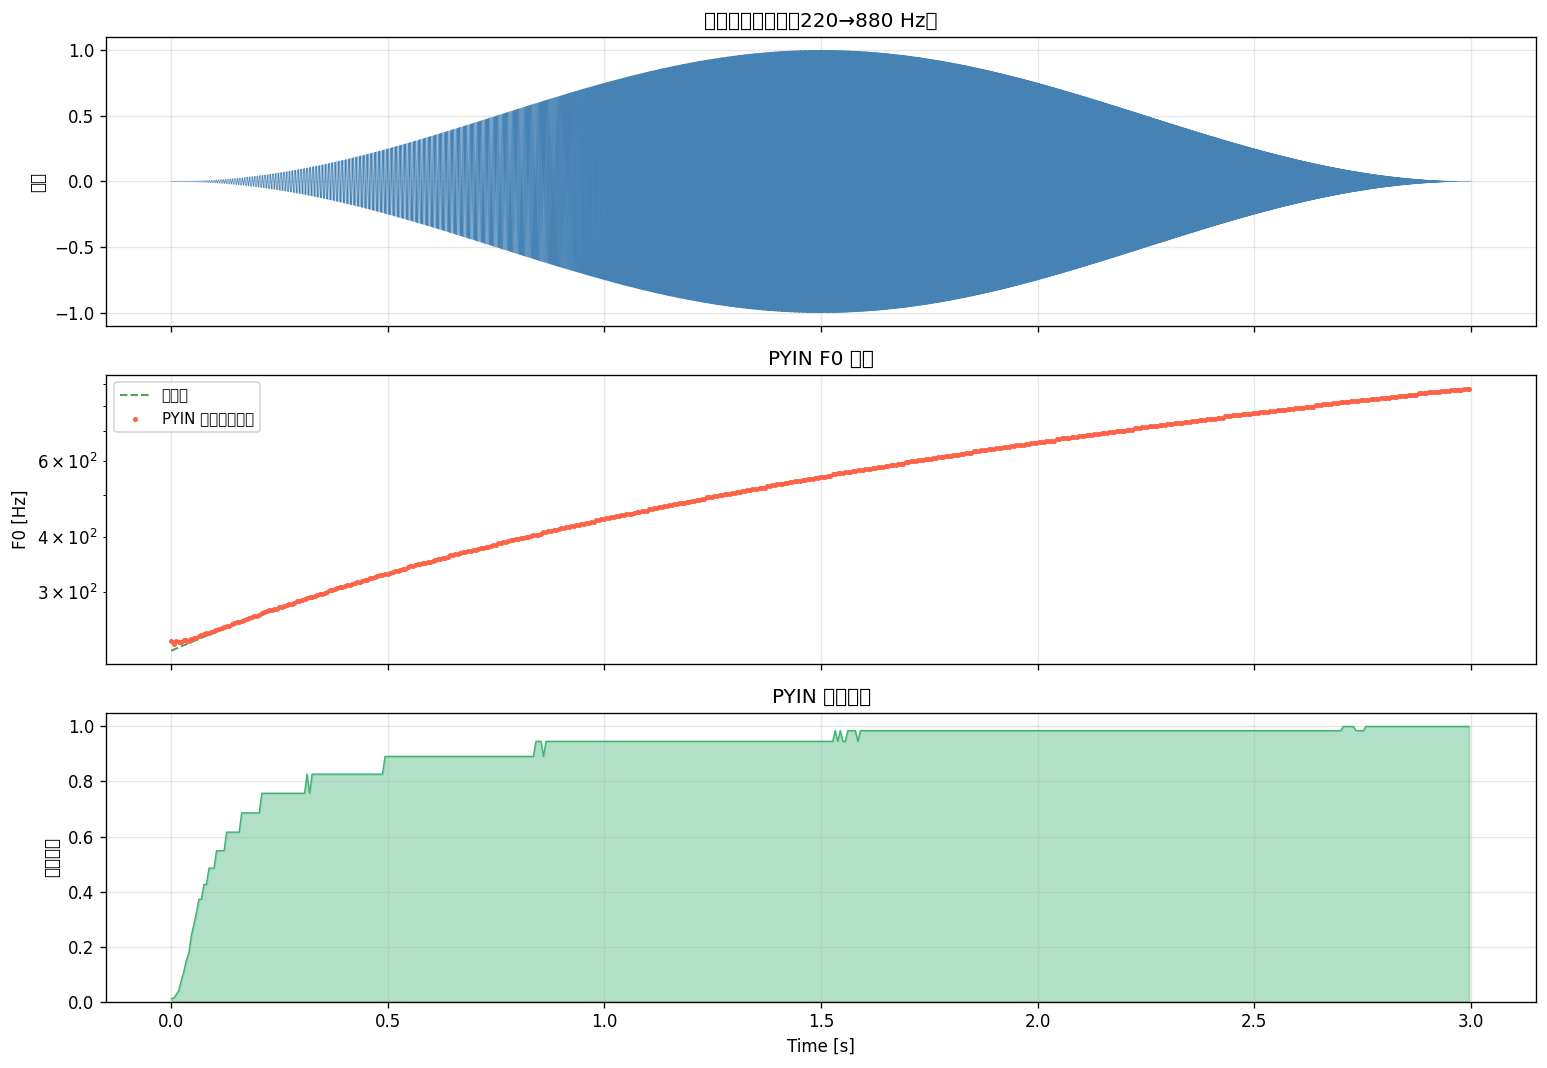

有声フレーム: 517/517
F0 誤差: 平均 1.24 Hz, 最大 11.74 Hz


In [3]:
# グライド音に PYIN を適用
f0_pyin, voiced_flag, voiced_probs = librosa.pyin(
    wave_glide, sr=SR,
    fmin=librosa.note_to_hz('A2'),
    fmax=librosa.note_to_hz('A6'),
    hop_length=HOP
)

t_frames = librosa.frames_to_time(np.arange(len(f0_pyin)), sr=SR, hop_length=HOP)
t_wave   = np.arange(len(wave_glide)) / SR

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# 波形
axes[0].plot(t_wave, wave_glide, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('振幅')
axes[0].set_title('グライド音波形（220→880 Hz）')

# F0 追跡
axes[1].plot(t_wave, f0_glide_true, 'g--', linewidth=1.2, label='理論値', alpha=0.7)
axes[1].scatter(t_frames[voiced_flag], f0_pyin[voiced_flag],
                s=4, color='tomato', label='PYIN 推定（有声）', zorder=3)
axes[1].set_ylabel('F0 [Hz]')
axes[1].set_title('PYIN F0 追跡')
axes[1].legend(fontsize=9)
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(ticker := plt.FuncFormatter(lambda v, _: f'{v:.0f}'))

# 有声確率
axes[2].fill_between(t_frames, voiced_probs, alpha=0.4, color='mediumseagreen')
axes[2].plot(t_frames, voiced_probs, linewidth=0.8, color='mediumseagreen')
axes[2].set_ylabel('有声確率')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('PYIN 有声確率')
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(DATA_DIR / 'pyin_glide.png', bbox_inches='tight')
plt.show()

# 誤差統計
valid = voiced_flag & ~np.isnan(f0_pyin)
t_valid_frames = t_frames[valid]
# 理論値との対応（近い時刻を参照）
f0_theory_at_frames = np.interp(t_valid_frames, t_wave, f0_glide_true)
errors = np.abs(f0_pyin[valid] - f0_theory_at_frames)
print(f'有声フレーム: {valid.sum()}/{len(valid)}')
print(f'F0 誤差: 平均 {errors.mean():.2f} Hz, 最大 {errors.max():.2f} Hz')

---
## 3. メロディーの F0 追跡と音符認識

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 12525 (\N{KATAKANA LETTER RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_8

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:50: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1828042876.py:51: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_80

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/pyt

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31934 (\N{CJK UNIFIED IDEOGRAPH-7CBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32209 (\N{CJK UNIFIED IDEOGRAPH-7DD1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36196 (\N{CJK UNIFIED IDEOGRAPH-8D64}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


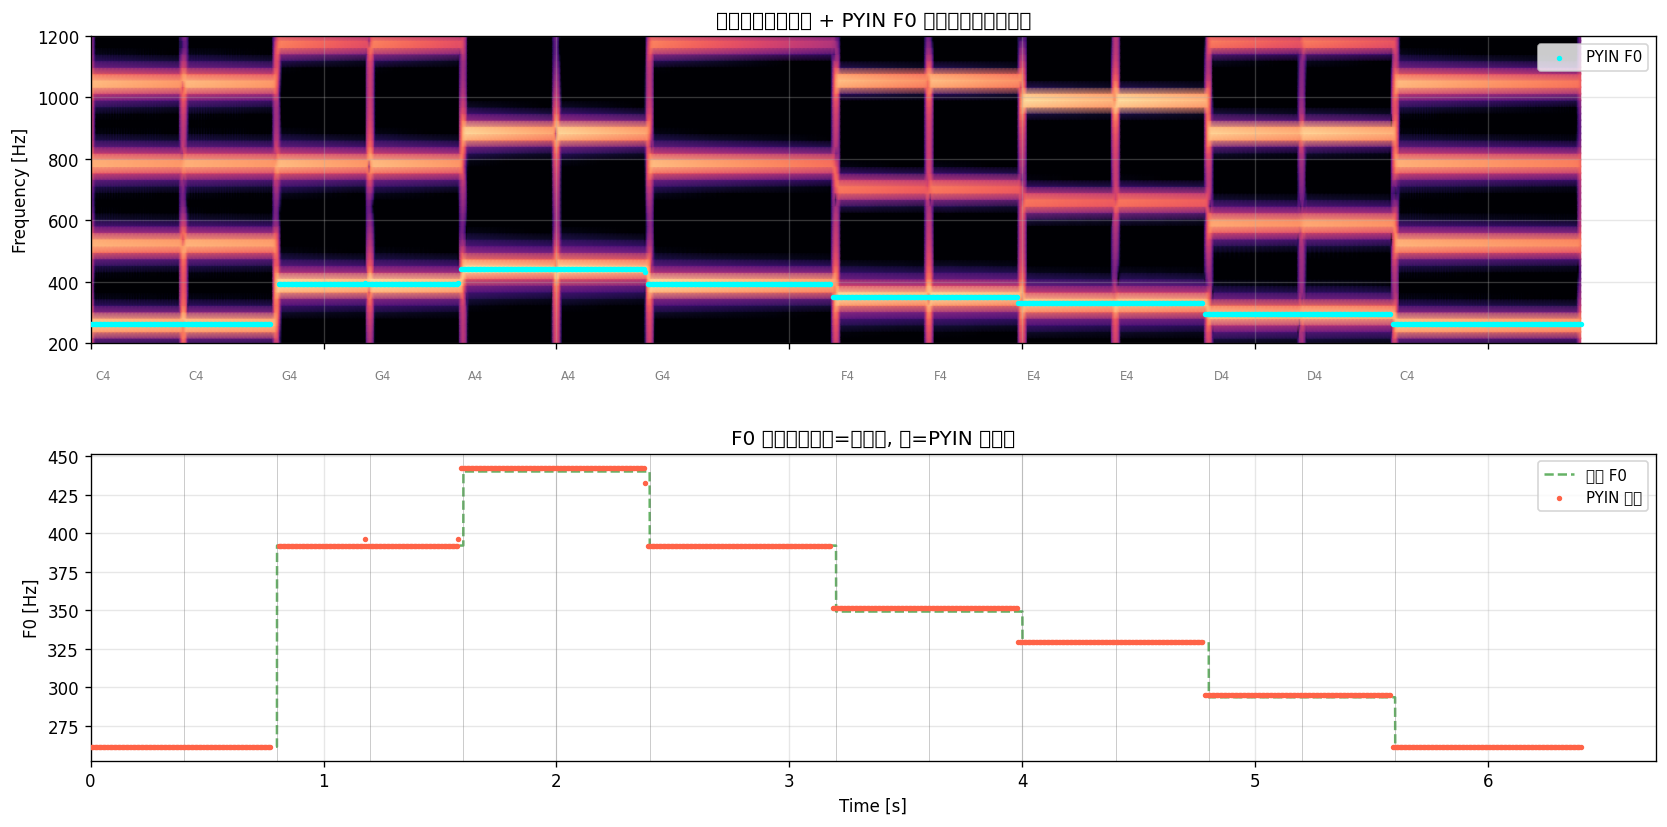

In [4]:
f0_mel, vf_mel, vp_mel = librosa.pyin(
    wave_melody, sr=SR,
    fmin=librosa.note_to_hz('C3'),
    fmax=librosa.note_to_hz('C6'),
    hop_length=HOP
)

t_mel_frames = librosa.frames_to_time(np.arange(len(f0_mel)), sr=SR, hop_length=HOP)
t_mel_wave   = np.arange(len(wave_melody)) / SR

# 推定 F0 を音名に変換
def hz_to_note(hz):
    if np.isnan(hz) or hz <= 0:
        return '—'
    midi = 12 * np.log2(hz / 440) + 69
    return librosa.midi_to_note(int(round(midi)))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# スペクトログラム + F0
D = librosa.stft(wave_melody, n_fft=2048, hop_length=HOP)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
freqs_sg = librosa.fft_frequencies(sr=SR, n_fft=2048)
axes[0].pcolormesh(t_mel_frames, freqs_sg, S_db[:, :len(t_mel_frames)],
                   shading='gouraud', cmap='magma', vmin=-60, vmax=0)
axes[0].scatter(t_mel_frames[vf_mel], f0_mel[vf_mel],
                s=5, color='cyan', zorder=3, label='PYIN F0')
axes[0].set_ylim(200, 1200)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_title('スペクトログラム + PYIN F0 追跡（きらきら星）')
axes[0].legend(fontsize=9)

# 理論値と推定値を比較
t_true = t_mel_wave
axes[1].plot(t_true, f0_melody_true, 'g--', linewidth=1.5, alpha=0.6, label='理論 F0')
axes[1].scatter(t_mel_frames[vf_mel], f0_mel[vf_mel],
                s=5, color='tomato', label='PYIN 推定', zorder=3)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('F0 [Hz]')
axes[1].set_title('F0 推定精度（緑=理論値, 赤=PYIN 推定）')
axes[1].legend(fontsize=9)

# 各音符の境界を縦線で描画
t_cursor = 0
for note, dur in MELODY:
    axes[1].axvline(t_cursor, color='gray', linewidth=0.6, alpha=0.4)
    axes[1].text(t_cursor + 0.02, 500, note, fontsize=7, color='gray')
    t_cursor += dur

plt.tight_layout()
plt.savefig(DATA_DIR / 'pyin_melody.png', bbox_inches='tight')
plt.show()

---
## 4. F0 推定手法の比較

同じグライド音に対して ACF・HPS・ケプストラム・PYIN を適用し、精度と安定性を比較する。

/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1839928245.py:69: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1839928245.py:69: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1839928245.py:69: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1839928245.py:69: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsbr_800000gn/T/ipykernel_89293/1839928245.py:69: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ff/3mkkd9nd3zq7lxyzbrsb

/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12465 (\N{KATAKANA LETTER KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/github/synth-lab/research/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dolphilia/git

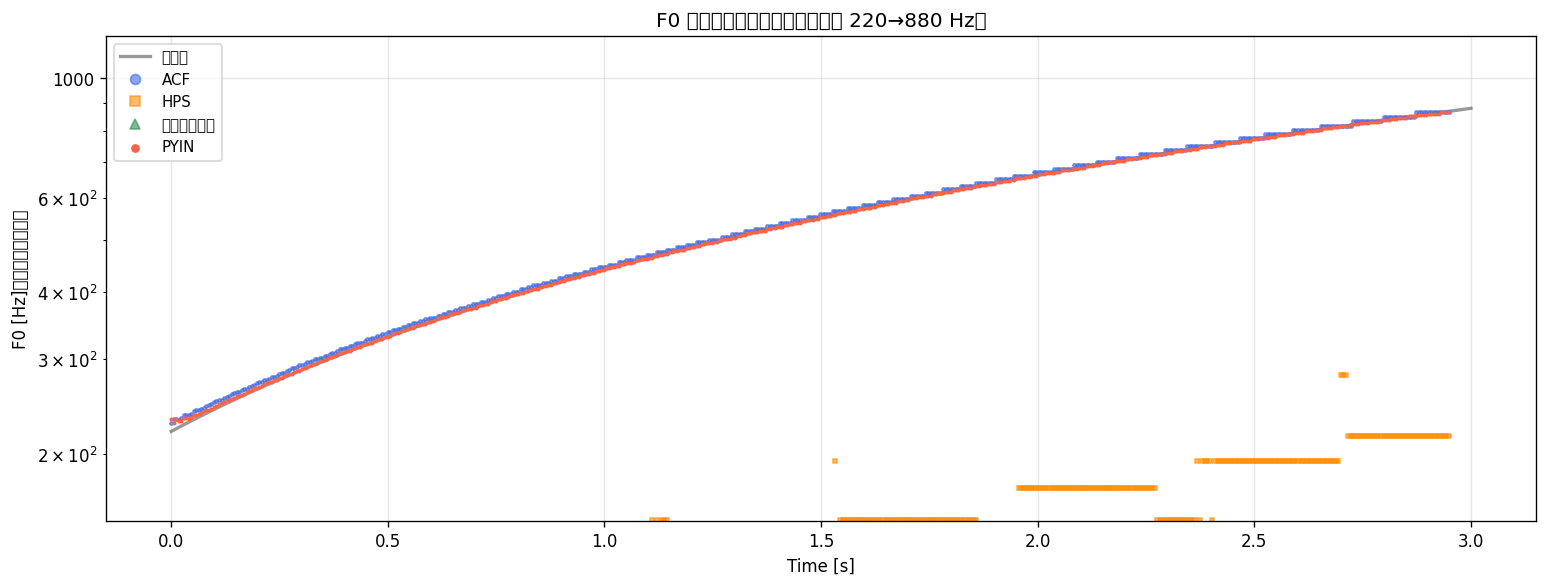


手法ごとの F0 誤差（RMSE セント）:
  ACF         : 25.7 セント
  HPS         : 2360.6 セント
  ケプストラム      : 3146.8 セント
  PYIN        : 9.2 セント


In [5]:
def f0_acf(frame, sr, fmin=80, fmax=2000):
    """自己相関法"""
    corr = np.correlate(frame, frame, 'full')[len(frame)-1:]
    lo, hi = int(sr/fmax), int(sr/fmin)
    if hi >= len(corr): return np.nan
    peak = lo + np.argmax(corr[lo:hi])
    return sr / peak if peak > 0 else np.nan


def f0_hps(frame, sr, n_harm=5, fmin=80, fmax=2000):
    """高調波積スペクトル法"""
    X = np.abs(rfft(frame * np.hanning(len(frame))))
    hps = X.copy()
    for h in range(2, n_harm+1):
        ds = X[::h]
        hps[:len(ds)] *= ds
    fq = rfftfreq(len(frame), 1/sr)
    lo = np.searchsorted(fq, fmin)
    hi = np.searchsorted(fq, fmax)
    if lo >= hi: return np.nan
    return fq[lo + np.argmax(hps[lo:hi])]


def f0_cepstrum(frame, sr, fmin=80, fmax=2000):
    """ケプストラム法"""
    X = np.abs(rfft(frame * np.hanning(len(frame))))
    cep = np.abs(rfft(np.log(X + 1e-10)))
    # ケプストラム軸（ケフレンシー）をHz変換
    quef_freqs = np.arange(len(cep)) / (len(X) / sr)
    lo = np.searchsorted(quef_freqs, fmin)
    hi = np.searchsorted(quef_freqs, fmax)
    if lo >= hi: return np.nan
    return quef_freqs[lo + np.argmax(cep[lo:hi])]


# フレームごとに各手法で F0 推定
FRAME_SZ = 2048
N_FRAMES = (len(wave_glide) - FRAME_SZ) // HOP + 1

results_acf = []
results_hps = []
results_cep = []
t_comp = []

for i in range(N_FRAMES):
    frame = wave_glide[i*HOP : i*HOP+FRAME_SZ]
    t_comp.append(i * HOP / SR)
    results_acf.append(f0_acf(frame, SR))
    results_hps.append(f0_hps(frame, SR))
    results_cep.append(f0_cepstrum(frame, SR))

t_comp     = np.array(t_comp)
t_wave_g   = np.arange(len(wave_glide)) / SR

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_wave_g, f0_glide_true, 'k-', linewidth=2, label='理論値', alpha=0.4)
ax.plot(t_comp, results_acf, 'o', markersize=2, alpha=0.6, label='ACF', color='royalblue')
ax.plot(t_comp, results_hps, 's', markersize=2, alpha=0.6, label='HPS', color='darkorange')
ax.plot(t_comp, results_cep, '^', markersize=2, alpha=0.6, label='ケプストラム', color='seagreen')
ax.scatter(t_mel_frames[:N_FRAMES] if len(t_mel_frames)>N_FRAMES else t_frames[:N_FRAMES],
           f0_pyin[:N_FRAMES], s=2, color='tomato', label='PYIN', zorder=4)
ax.set_yscale('log')
ax.set_ylim(150, 1200)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}'))
ax.set_xlabel('Time [s]')
ax.set_ylabel('F0 [Hz]（対数スケール）')
ax.set_title('F0 推定手法の比較（グライド音 220→880 Hz）')
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'f0_comparison.png', bbox_inches='tight')
plt.show()

# 定量評価
def rmse_cents(estimated, t_est, true_wave, t_true_wave):
    valid = [e for e in estimated if e is not None and not np.isnan(e) and e > 0]
    if not valid: return np.nan
    est  = np.array([e if (e is not None and not np.isnan(e) and e>0) else np.nan
                     for e in estimated])
    th   = np.interp(t_est, t_true_wave, true_wave)
    mask = ~np.isnan(est) & (est > 0)
    if mask.sum() == 0: return np.nan
    cents_err = 1200 * np.abs(np.log2(est[mask] / th[mask]))
    return float(np.sqrt(np.mean(cents_err**2)))

print('\n手法ごとの F0 誤差（RMSE セント）:')
for name, est in [('ACF',       results_acf),
                  ('HPS',       results_hps),
                  ('ケプストラム', results_cep),
                  ('PYIN',      list(f0_pyin[:N_FRAMES]))]:
    t_est = t_comp if name != 'PYIN' else t_frames[:N_FRAMES]
    err = rmse_cents(est, t_est, f0_glide_true, t_wave_g)
    print(f'  {name:12s}: {err:.1f} セント' if not np.isnan(err) else f'  {name:12s}: 計算不可')

---
## まとめ

| 確認できたこと | 詳細 |
|---|---|
| PYIN の有声確率 | 音の立ち上がりと消えかけで確率が低下する様子が見える |
| グライド追跡 | PYIN はグライド全域で安定して F0 を追跡できる |
| メロディー追跡 | 音符の境界で NaN になり、有声区間では正確に音名を推定できる |
| 手法比較 | ACF は高速だがオクターブエラーが出る。PYIN は HMM で時間方向に滑らか |

### 推奨する手法の使い分け

| 状況 | 推奨手法 |
|---|---|
| 単一の安定した音 | ACF / ケプストラム（高速） |
| メロディー・歌声 | PYIN（有声/無声判定込み） |
| 多倍音楽器（ギター等） | HPS |
| ノイズ環境・高精度 | PYIN / CREPE（深層学習） |

### 次に試すこと

- `hop_length` を変えて時間分解能と精度のトレードオフを確認する
- ビブラート（周波数の周期的変動）音に対して PYIN を適用する
- CREPE（`pip install crepe`）をインストールして比較する